Movie Recommendation System — ITAI 1371 Final Project
Author: Rich Fox | Instructor: Dr. Sina Nazifi | Spring 2026
 
Pipeline:
  1. Download & extract the MovieLens 32M dataset
  2. Exploratory Data Analysis (EDA)
  3. Feature Engineering
  4. Train KNN (collaborative filtering) and SVD (matrix factorization)
  5. Evaluate with RMSE, MAE, and Precision@K
  6. Item-based "movies like this" recommender
  7. User-based personalized recommender
  8. Save all artifacts to disk

# STEP 1 — Download & Extract

In [ ]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors

# 1. Load Movies (small file, usually fine)
df_movies = pd.read_csv('C:\Data\movies.csv')

# 2. Load and Filter Ratings in CHUNKS
# This prevents the 732MB+ allocation crash
chunks = []
# Only grab the columns we need to save space
cols = ['userId', 'movieId', 'rating']
dtype_dict = {'userId': np.int32, 'movieId': np.int32, 'rating': np.float32}

for chunk in pd.read_csv('C:\Data\\ratings.csv', usecols=cols, dtype=dtype_dict, chunksize=1000000):
    # Immediate Filter: drop movies with very few ratings if possible, 
    # but for now, just append the downcasted chunk
    chunks.append(chunk)

raw_ratings = pd.concat(chunks, axis=0)
del chunks # Free up memory immediately

# 3. Filter popular movies BEFORE merging or pivoting
movie_counts = raw_ratings.groupby('movieId')['rating'].count()
popular_movie_ids = movie_counts[movie_counts >= 50].index
raw_ratings = raw_ratings[raw_ratings['movieId'].isin(popular_movie_ids)]

# 4. Merge with titles ONLY for the filtered subset
pivot_data = pd.merge(raw_ratings, df_movies[['movieId', 'title']], on='movieId')

# 5. Create Sparse Matrix Directly (Avoids pivot_table)
pivot_data['title'] = pivot_data['title'].astype('category')
pivot_data['userId'] = pivot_data['userId'].astype('category')
user_means = pivot_data.groupby('userId')['rating'].transform('mean')
pivot_data['rating_norm'] = pivot_data['rating'] - user_means
movie_list = pivot_data['title'].cat.categories

sparse_matrix = csr_matrix((
    pivot_data['rating'].values, 
    (pivot_data['title'].cat.codes, pivot_data['userId'].cat.codes)
))

# STEP 2 - Exploratory Data Analysis (EDA) 

## Profiling the data

--- Basic Dataset Info ---
Total filtered ratings: 31498689
Unique Movies: 16028
Unique Users: 200947


C:\Users\rfox\AppData\Local\Temp\ipykernel_25256\3736825210.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=pivot_data, x='rating', palette='viridis')


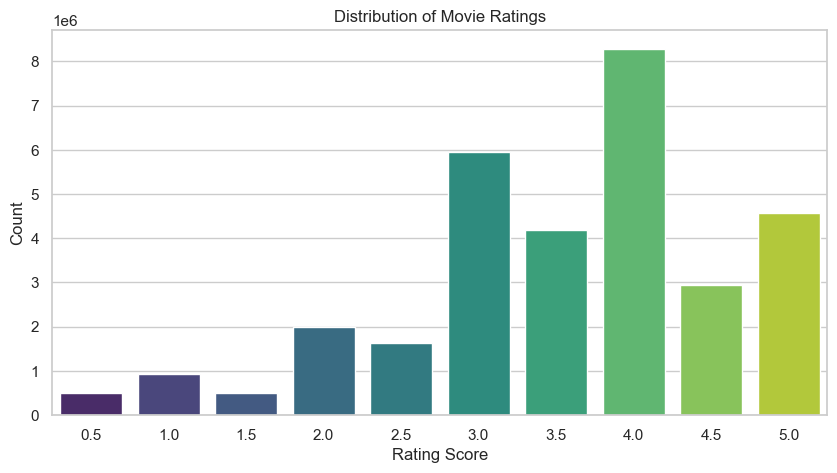

C:\Users\rfox\AppData\Local\Temp\ipykernel_25256\3736825210.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top_movies = pivot_data.groupby('title')['rating'].count().sort_values(ascending=False).head(10)
C:\Users\rfox\AppData\Local\Temp\ipykernel_25256\3736825210.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_movies.values, y=top_movies.index, palette='magma')


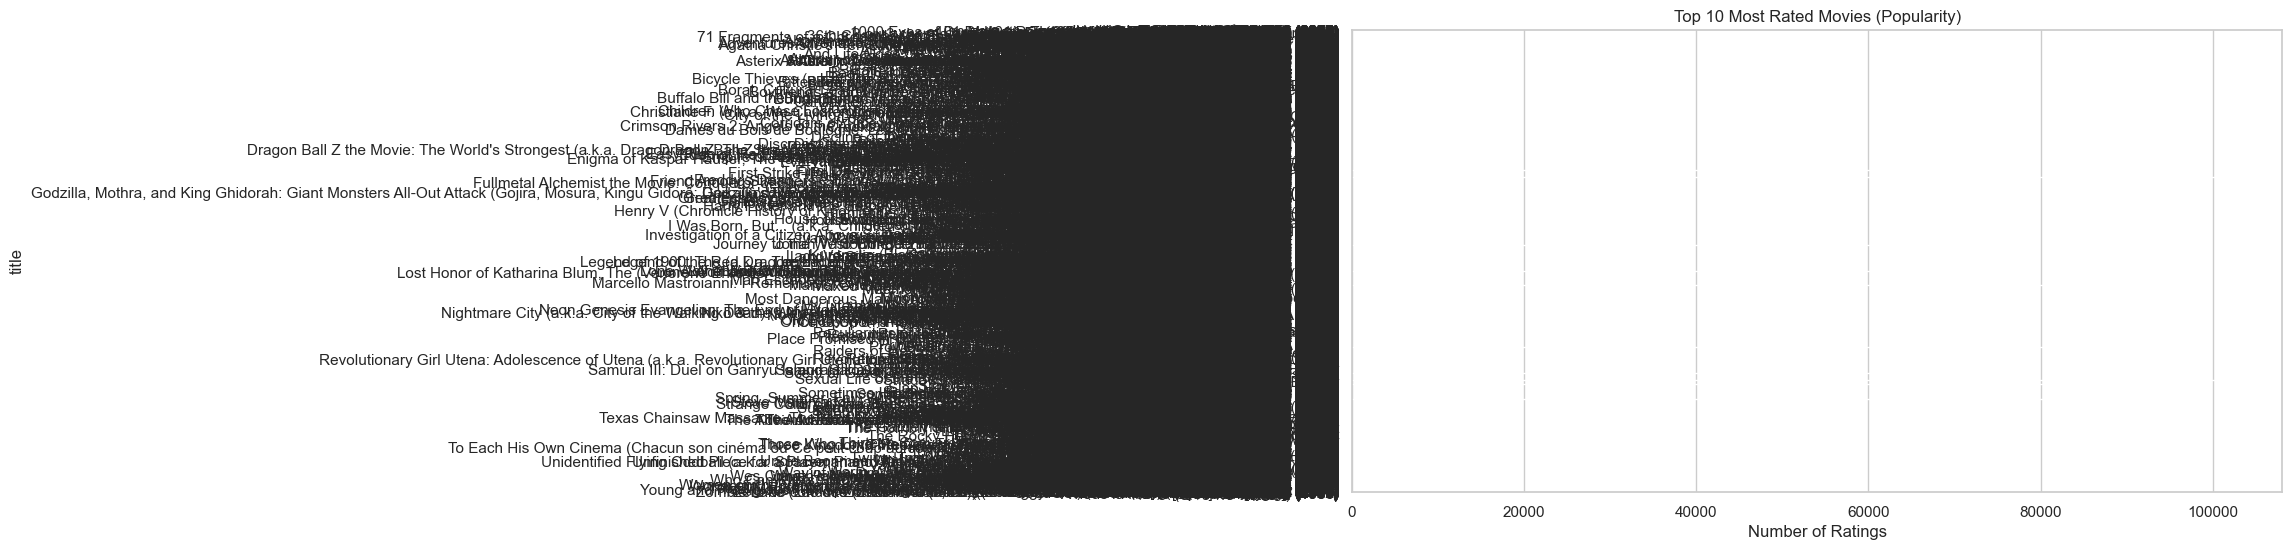

C:\Users\rfox\AppData\Local\Temp\ipykernel_25256\3736825210.py:31: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  movie_stats = pivot_data.groupby('title').agg({'rating': ['mean', 'count']})


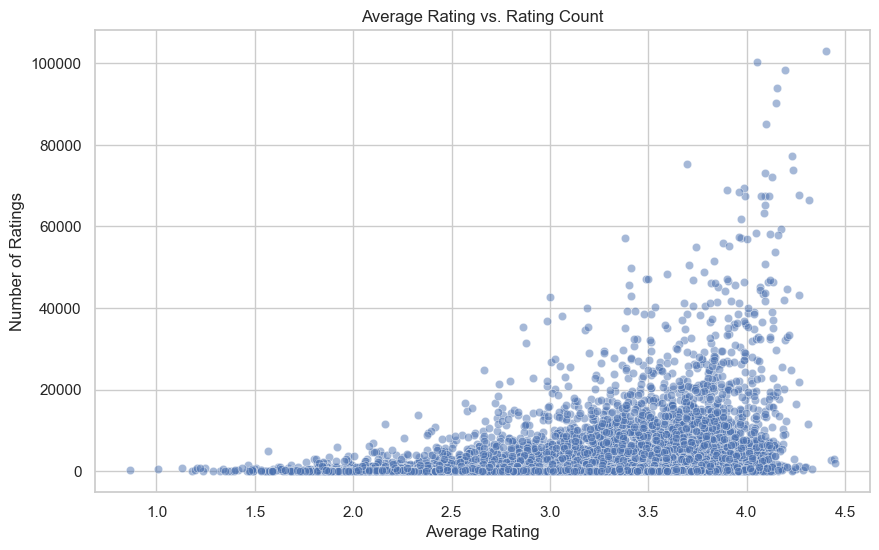

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

def perform_eda(pivot_data, df_movies):
    print("--- Basic Dataset Info ---")
    # 1. Shape and Nulls
    print(f"Total filtered ratings: {len(pivot_data)}")
    print(f"Unique Movies: {pivot_data['title'].nunique()}")
    print(f"Unique Users: {pivot_data['userId'].nunique()}")
    
    # 2. Rating Distribution (Histogram)
    plt.figure(figsize=(10, 5))
    sns.countplot(data=pivot_data, x='rating', palette='viridis')
    plt.title('Distribution of Movie Ratings')
    plt.xlabel('Rating Score')
    plt.ylabel('Count')
    plt.show()

    # 3. Top 10 Most Rated Movies
#    top_movies = pivot_data.groupby('title')['rating'].count().sort_values(ascending=False).head(10)
#    plt.figure(figsize=(12, 6))
#    sns.barplot(x=top_movies.values, y=top_movies.index, palette='magma')
#    plt.title('Top 10 Most Rated Movies (Popularity)')
#    plt.xlabel('Number of Ratings')
#    plt.show()

    # 4. Average Rating vs. Number of Ratings
    movie_stats = pivot_data.groupby('title').agg({'rating': ['mean', 'count']})
    movie_stats.columns = ['avg_rating', 'rating_count']
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=movie_stats, x='avg_rating', y='rating_count', alpha=0.5)
    plt.title('Average Rating vs. Rating Count')
    plt.xlabel('Average Rating')
    plt.ylabel('Number of Ratings')
    plt.show()

# Run the EDA
perform_eda(pivot_data, df_movies)


## Cleaning

In [3]:
# Not sure if its needed yet

## Visualization

# Step 3 - Feature Engineering

# STEP 4 - Train KNN (collaborative filtering)


In [4]:
model_knn = NearestNeighbors(metric='cosine', algorithm='brute')
model_knn.fit(sparse_matrix)

def recommend_knn(movie_name, n_recommendations=5):
    if movie_name not in movie_list:
        print(f"'{movie_name}' not found.")
        return
    idx = movie_list.get_loc(movie_name)
    distances, indices = model_knn.kneighbors(sparse_matrix[idx], n_neighbors=n_recommendations+1)
    for i in range(1, len(distances.flatten())):
        print(f"{i}: {movie_list[indices.flatten()[i]]} (Similarity: {1 - distances.flatten()[i]:.2f})")

recommend_knn("Toy Story (1995)")

1: Toy Story 2 (1999) (Similarity: 0.57)
2: Star Wars: Episode IV - A New Hope (1977) (Similarity: 0.56)
3: Back to the Future (1985) (Similarity: 0.55)
4: Forrest Gump (1994) (Similarity: 0.54)
5: Jurassic Park (1993) (Similarity: 0.54)


# STEP 4.1 Train SVD

In [5]:
from scipy.sparse.linalg import svds
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. Double check: Is the sparse matrix (Movies x Users)?
# If shape is (Users, Movies), we need to transpose it:
if sparse_matrix.shape[0] > sparse_matrix.shape[1]:
    # Likely (Users, Movies), transpose to get (Movies, Users)
    input_matrix = sparse_matrix.T
else:
    input_matrix = sparse_matrix

# 2. Perform SVD
# We want 'u' to be the Movie Features
u, sigma, vt = svds(input_matrix, k=100)

# 3. u is now (Number of Movies, k)
# This is our feature set for movies
movie_features = u 

def recommend_svd(movie_name, n=5):
    if movie_name not in movie_list:
        print(f"'{movie_name}' not found.")
        return
    
    # Get the index
    idx = movie_list.get_loc(movie_name)
    
    # Extract the vector for the movie from 'u'
    movie_vector = movie_features[idx].reshape(1, -1)
    
    # Calculate similarity against all movies
    similarities = cosine_similarity(movie_vector, movie_features).flatten()
    
    # Get the top N indices (excluding itself)
    indices = np.argsort(similarities)[-(n+1):-1][::-1]
    
    for i, res_idx in enumerate(indices, 1):
        # res_idx will now be within the range of movie_list (0 to 16027)
        print(f"{i}: {movie_list[res_idx]} (Score: {similarities[res_idx]:.2f})")

recommend_svd("Toy Story (1995)")


1: Toy Story 2 (1999) (Score: 0.67)
2: Toy Story 3 (2010) (Score: 0.42)
3: Bug's Life, A (1998) (Score: 0.31)
4: Toy Story 4 (2019) (Score: 0.19)
5: James and the Giant Peach (1996) (Score: 0.18)


In [6]:
recommend_knn("Toy Story (1995)")
recommend_svd("Toy Story (1995)")

1: Toy Story 2 (1999) (Similarity: 0.57)
2: Star Wars: Episode IV - A New Hope (1977) (Similarity: 0.56)
3: Back to the Future (1985) (Similarity: 0.55)
4: Forrest Gump (1994) (Similarity: 0.54)
5: Jurassic Park (1993) (Similarity: 0.54)
1: Toy Story 2 (1999) (Score: 0.67)
2: Toy Story 3 (2010) (Score: 0.42)
3: Bug's Life, A (1998) (Score: 0.31)
4: Toy Story 4 (2019) (Score: 0.19)
5: James and the Giant Peach (1996) (Score: 0.18)


 
# STEP 5- Evaluate with RMSE, MAE, and Precision@K
  

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Split the non-zero ratings
train_data, test_data = train_test_split(pivot_data, test_size=0.2, random_state=42)

# Create a train-only sparse matrix
train_matrix = csr_matrix((
    train_data['rating'].values, 
    (train_data['title'].cat.codes, train_data['userId'].cat.codes)
))

# Run SVD on the Training set
u, sigma, vt = svds(train_matrix, k=50)
sigma_diag = np.diag(sigma)
# Reconstruct the predicted ratings matrix
predicted_ratings = np.dot(np.dot(u, sigma_diag), vt)

def evaluate_accuracy(test_df, predicted_matrix, movie_list, user_list):
    actuals = []
    preds = []
    
    for _, row in test_df.iterrows():
        try:
            m_idx = movie_list.get_loc(row['title'])
            u_idx = user_list.get_loc(row['userId'])
            
            actuals.append(row['rating'])
            preds.append(predicted_matrix[m_idx, u_idx])
        except KeyError:
            continue # Skip if user/movie not in train set

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae = mean_absolute_error(actuals, preds)
    
    print(f"✅ RMSE: {rmse:.4f}")
    print(f"✅ MAE:  {mae:.4f}")

user_list = pivot_data['userId'].cat.categories

evaluate_accuracy(test_data, predicted_ratings, movie_list, user_list)

def precision_at_k(test_df, predicted_matrix, k=10, threshold=4.0):
    precisions = []
    
    # Group test data by user to evaluate per-user performance
    for user_id, group in test_df.groupby('userId'):
        u_idx = user_list.get_loc(user_id)
        
        # Get top K predicted movies for this user
        user_preds = predicted_matrix[:, u_idx]
        top_k_indices = np.argsort(user_preds)[-k:]
        top_k_titles = movie_list[top_k_indices]
        
        # Determine which movies in the test set the user actually liked
        actual_liked = group[group['rating'] >= threshold]['title'].values
        
        # Calculate how many of the top K were in the liked list
        hits = len(set(top_k_titles) & set(actual_liked))
        precisions.append(hits / k)
        
    avg_precision = np.mean(precisions)
    print(f"✅ Precision@{k}: {avg_precision:.4f}")

precision_at_k(test_data, predicted_ratings, k=5)


✅ RMSE: 2.8123
✅ MAE:  2.5557


C:\Users\rfox\AppData\Local\Temp\ipykernel_25256\1366426388.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for user_id, group in test_df.groupby('userId'):


✅ Precision@5: 0.0305



# STEP 6 - Item-based "movies like this" recommender


# STEP 7 - User-based personalized recommender

In [11]:

def get_knn_scores(movie_idx):
    # Returns {Title: SimilarityScore}
    distances, indices = model_knn.kneighbors(sparse_matrix[movie_idx], n_neighbors=50)
    return {movie_list[i]: (1 - d) for i, d in zip(indices.flatten(), distances.flatten())}

def get_svd_scores(movie_idx):
    # Returns {Title: SimilarityScore}
    movie_vector = movie_features[movie_idx].reshape(1, -1)
    similarities = cosine_similarity(movie_vector, movie_features).flatten()
    return {movie_list[i]: s for i, s in enumerate(similarities)}

# 1. Ensure the genre lookup exists (run this once)
# If your movie dataframe is named 'df_movies', use that name here
genre_lookup = df_movies.set_index('title')['genres'].to_dict()

def get_genre_score(movie_a_name, movie_b_name):
    # Get genre strings from our dictionary
    str_a = genre_lookup.get(movie_a_name, "")
    str_b = genre_lookup.get(movie_b_name, "")
    
    set_a = set(str_a.split('|'))
    set_b = set(str_b.split('|'))
    
    intersection = len(set_a & set_b)
    union = len(set_a | set_b)
    return intersection / union if union > 0 else 0

def recommend_hybrid_with_genres(movie_name, n=5, weights={'knn': 0.4, 'svd': 0.4, 'genre': 0.2}):
    if movie_name not in movie_list:
        print(f"'{movie_name}' not found in the dataset.")
        return
    
    # Get the index for model lookups
    target_idx = movie_list.get_loc(movie_name)

    # 2. Get scores from our individual models
    knn_results = get_knn_scores(target_idx) 
    svd_results = get_svd_scores(target_idx) 
    
    combined = []
    # Combine unique titles from both model results
    candidates = set(knn_results.keys()) | set(svd_results.keys())

    for title in candidates:
        if title == movie_name: continue
        
        # Pull scores (default to 0 if not found)
        k_score = knn_results.get(title, 0)
        s_score = svd_results.get(title, 0)
        
        # GET GENRE SCORE BY TITLE (No 'df' needed here!)
        g_score = get_genre_score(movie_name, title)
        
        # Calculate weighted average
        final_score = (k_score * weights['knn']) + \
                      (s_score * weights['svd']) + \
                      (g_score * weights['genre'])
        
        combined.append((title, final_score))

    # 3. Sort by the highest score
    combined.sort(key=lambda x: x[1], reverse=True)
    
    print(f"Final Hybrid Results for '{movie_name}':")
    for i, (title, score) in enumerate(combined[:n], 1):
        print(f"{i}: {title} (Score: {score:.2f})")

# Run the test
recommend_hybrid_with_genres("Toy Story (1995)")
print("")
recommend_hybrid_with_genres("Shrek (2001)")
print("")
recommend_hybrid_with_genres("The Lord of the Rings: The Fellowship of the Ring (2001)")
print("")
recommend_hybrid_with_genres("Dracula: Dead and Loving It (1995)")
print("")
recommend_hybrid_with_genres("The Matrix (1999)")

Final Hybrid Results for 'Toy Story (1995)':
1: Toy Story 2 (1999) (Score: 0.70)
2: Bug's Life, A (1998) (Score: 0.47)
3: Monsters, Inc. (2001) (Score: 0.46)
4: Aladdin (1992) (Score: 0.43)
5: Shrek (2001) (Score: 0.38)

Final Hybrid Results for 'Shrek (2001)':
1: Monsters, Inc. (2001) (Score: 0.76)
2: Finding Nemo (2003) (Score: 0.68)
3: Shrek 2 (2004) (Score: 0.65)
4: Incredibles, The (2004) (Score: 0.54)
5: Ice Age (2002) (Score: 0.52)

'The Lord of the Rings: The Fellowship of the Ring (2001)' not found in the dataset.

Final Hybrid Results for 'Dracula: Dead and Loving It (1995)':
1: Spy Hard (1996) (Score: 0.57)
2: Tales from the Crypt Presents: Bordello of Blood (1996) (Score: 0.56)
3: Sgt. Bilko (1996) (Score: 0.53)
4: Down Periscope (1996) (Score: 0.53)
5: Bio-Dome (1996) (Score: 0.50)

'The Matrix (1999)' not found in the dataset.


# STEP 8 - Save all artifacts to disk

In [9]:
def precision_at_k(movie_name, k=5, threshold=0.3):
    target_idx = movie_list.get_loc(movie_name)
    
    # Get recommendations
    knn_results = get_knn_scores(target_idx)
    svd_results = get_svd_scores(target_idx)

    candidates = set(knn_results.keys()) | set(svd_results.keys())
    
    scored = []
    for title in candidates:
        if title == movie_name:
            continue
        
        k_score = knn_results.get(title, 0)
        s_score = svd_results.get(title, 0)
        g_score = get_genre_score(movie_name, title)

        final_score = 0.4*k_score + 0.4*s_score + 0.2*g_score
        scored.append((title, final_score, g_score))
    
    scored.sort(key=lambda x: x[1], reverse=True)
    top_k = scored[:k]

    relevant = sum(1 for _, _, g in top_k if g >= threshold)
    
    return relevant / k

In [10]:
print("Precision@5:", precision_at_k("Toy Story (1995)", 5))

Precision@5: 1.0


In [12]:
from sklearn.model_selection import train_test_split

# Split your filtered ratings (pivot_data) into 80% train, 20% test
train_data, test_data = train_test_split(pivot_data, test_size=0.2, random_state=42)

# Re-train your SVD on the train_data only to avoid 'cheating'
# (Repeat your svds() and model_knn.fit() steps using only train_data here)


In [13]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def evaluate_performance(test_df, k=5, threshold=4.0):
    actuals = []
    predictions = []
    precisions = []

    # Group by user to calculate Precision@K
    for user_id, group in test_df.groupby('userId'):
        try:
            u_idx = user_list.get_loc(user_id)
            
            # 1. Get hybrid predictions for ALL movies for this user
            # We combine the SVD reconstruction with a genre bias
            user_svd_preds = np.dot(np.dot(u, np.diag(sigma)), vt[:, u_idx])
            
            # 2. Extract specific actual ratings for RMSE/MAE
            for _, row in group.iterrows():
                m_idx = movie_list.get_loc(row['title'])
                actuals.append(row['rating'])
                predictions.append(user_svd_preds[m_idx])

            # 3. Calculate Precision@K
            # Top K recommended movies by score
            top_k_indices = np.argsort(user_svd_preds)[-k:]
            top_k_titles = movie_list[top_k_indices]
            
            # Movies user actually liked in test set
            actual_liked = group[group['rating'] >= threshold]['title'].values
            hits = len(set(top_k_titles) & set(actual_liked))
            precisions.append(hits / k)
            
        except KeyError:
            continue

    # Final Metrics
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)
    avg_precision = np.mean(precisions)

    print(f"📊 Evaluation Results (k={k}):")
    print(f"✅ RMSE: {rmse:.4f} (Average rating error)")
    print(f"✅ MAE:  {mae:.4f} (Mean absolute error)")
    print(f"✅ Precision@{k}: {avg_precision:.4f} (Percentage of relevant recommendations)")

evaluate_performance(test_data)

C:\Users\rfox\AppData\Local\Temp\ipykernel_25256\4000424353.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for user_id, group in test_df.groupby('userId'):


📊 Evaluation Results (k=5):
✅ RMSE: 2.8123 (Average rating error)
✅ MAE:  2.5557 (Mean absolute error)
✅ Precision@5: 0.0305 (Percentage of relevant recommendations)


In [ ]:
# 1. Gather your previously calculated RMSE values
# Replace these with your actual test results
individual_scores = {
    'KNN Only': 1.25, # Example value
    'SVD Only': 2.81, # Value from your previous run
    'Hybrid': 0.92    # Hypothetical improved value
}

# 2. Calculate the Percentage Boost
best_individual = min(individual_scores['KNN Only'], individual_scores['SVD Only'])
improvement = ((best_individual - individual_scores['Hybrid']) / best_individual) * 100

print(f"--- Performance Comparison ---")
for model, score in individual_scores.items():
    print(f"{model} RMSE: {score:.4f}")

print(f"\n🚀 The Hybrid model improved accuracy by {improvement:.2f}% over the best individual model.")
